# **BiLSTM + CRF on 30 Outlines**

In [2]:
# ==============================
# BiLSTM + CRF
# ==============================

!pip install keras-crf

import os
import zipfile
import json
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM
from tensorflow.keras.models import Model

from keras_crf import CRF

# ========================
# DATASET EXTRACTION
# ========================
zip_path = '/content/drive/MyDrive/Colab Notebooks/FYP /OOP Annotated.zip'
extract_path = '/content/extracted_data'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# ========================
# LOAD ANNOTATIONS
# ========================
def load_spacy_annotations(base_path):
    sentences, labels, tag_set = [], [], set()

    for root, dirs, files in os.walk(base_path):
        for file in files:
            if "annotations" in file and file.endswith(".json"):
                with open(os.path.join(root, file), "r", encoding="utf-8") as f:
                    data = json.load(f)

                for text, ann in data["annotations"]:
                    tokens = text.strip().split()
                    token_labels = ["O"] * len(tokens)

                    for start, end, label in ann.get("entities", []):
                        span = text[start:end]
                        for i, token in enumerate(tokens):
                            if span in token:
                                token_labels[i] = label
                                tag_set.add(label)

                    sentences.append(tokens)
                    labels.append(token_labels)

    return sentences, labels, tag_set

base_path = "/content/extracted_data/OOP Annotated"
sentences, labels, tag_set = load_spacy_annotations(base_path)

# ========================
# PREPROCESSING
# ========================
words = sorted(set(w for s in sentences for w in s))
tags = sorted(set(t for l in labels for t in l))

word2idx = {w: i+2 for i, w in enumerate(words)}
word2idx["PAD"] = 0
word2idx["UNK"] = 1

tag2idx = {t: i+1 for i, t in enumerate(tags)}
tag2idx["PAD"] = 0

idx2tag = {i: t for t, i in tag2idx.items()}

X = [[word2idx.get(w, 1) for w in s] for s in sentences]
y = [[tag2idx[t] for t in l] for l in labels]

MAXLEN = max(len(s) for s in X)

X = pad_sequences(X, maxlen=MAXLEN, padding="post", value=0)
y = pad_sequences(y, maxlen=MAXLEN, padding="post", value=0)

# ========================
# TRAIN TEST SPLIT
# ========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ========================
# BiLSTM + CRF MODEL
# ========================
input_layer = Input(shape=(MAXLEN,))
x = Embedding(len(word2idx), 128, mask_zero=True)(input_layer)
x = Bidirectional(LSTM(64, return_sequences=True))(x)

crf = CRF(len(tag2idx))
output = crf(x)

model = Model(input_layer, output)
model.compile(optimizer="adam", loss=crf.loss_function, metrics=[crf.accuracy])

model.summary()

# ========================
# TRAINING
# ========================
model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=30,
    validation_data=(X_test, y_test),
    verbose=1
)

# ========================
# EVALUATION
# ========================
y_pred = model.predict(X_test)

y_true_labels = []
y_pred_labels = []

for i in range(len(y_test)):
    for j in range(len(y_test[i])):
        if y_test[i][j] != tag2idx["PAD"]:
            y_true_labels.append(idx2tag[y_test[i][j]])
            y_pred_labels.append(idx2tag[y_pred[i][j]])

print(classification_report(y_true_labels, y_pred_labels, zero_division=0))


INFO: pip is looking at multiple versions of keras-crf to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of keras-crf to determine which version is compatible with other requirements. This could take a while.
ERROR: Cannot install keras-crf==0.0.1, keras-crf==0.0.2, keras-crf==0.0.3, keras-crf==0.0.4, keras-crf==0.1.0, keras-crf==0.1.1, keras-crf==0.2.0 and keras-crf==0.3.0 because these package versions have conflicting dependencies.

The conflict is caused by:
    keras-crf 0.3.0 depends on tensorflow-addons
    keras-crf 0.2.0 depends on tensorflow-addons
    keras-crf 0.1.1 depends on tensorflow-addons
    keras-crf 0.1.0 depends on tensorflow-addons
    keras-crf 0.0.4 depends on tensorflow-addons
    keras-crf 0.0.3 depends on tensorflow-addons
    keras-crf 0.0.2 depends on tensorflow-addons
    keras-crf 0.0.1 depends on tensorflow-addons

To fix this you could try to:
1. loosen the range o

ModuleNotFoundError: No module named 'keras_crf'

CRF layers could not be used due to incompatibility with TensorFlow 2.19.
To improve sequence representation and context-awareness, we added an attention layer on top of the BiLSTM.
This allows the model to weigh important tokens for tagging while remaining compatible with the current environment

# **BiLSTM + Attention**

Dataset extracted to: /content/extracted_data
Total sentences: 486
Sample sentence: ['Function-Oriented', 'Programming']
Sample labels: ['O', 'O']
Tags found: {'METHOD', 'TOPIC', 'CONCEPT', 'OTHERS'}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'attention_layer' (of type AttentionLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 58)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 58, 128)   │    152,064 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 58)        │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 58, 128)   │     98,816 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 58, 128)   │     16,640 │ bidirectional[0]… │
│ (AttentionLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 58, 6)     │        774 │ attention_layer[… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 268,294 (1.02 MB)

 Trainable params: 268,294 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 252ms/step - accuracy: 0.7651 - loss: 1.7724 - val_accuracy: 0.8614 - val_loss: 1.6080
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 251ms/step - accuracy: 0.8730 - loss: 1.4715 - val_accuracy: 0.8614 - val_loss: 0.7666
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.8760 - loss: 0.5927 - val_accuracy: 0.8624 - val_loss: 0.5021
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step - accuracy: 0.8856 - loss: 0.3965 - val_accuracy: 0.8624 - val_loss: 0.4749
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 252ms/step - accuracy: 0.8819 - loss: 0.3790 - val_accuracy: 0.8614 - val_loss: 0.4609
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - accuracy: 0.8698 - loss: 0.3921 - val_accuracy: 0.8614 - val_loss: 0.4539
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.8869 - loss: 0.3558 - val_accuracy: 0.8614 - val_loss: 0.4492
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 256ms/step - accuracy: 0.8815 - loss: 0.3578 - val_accuracy: 0

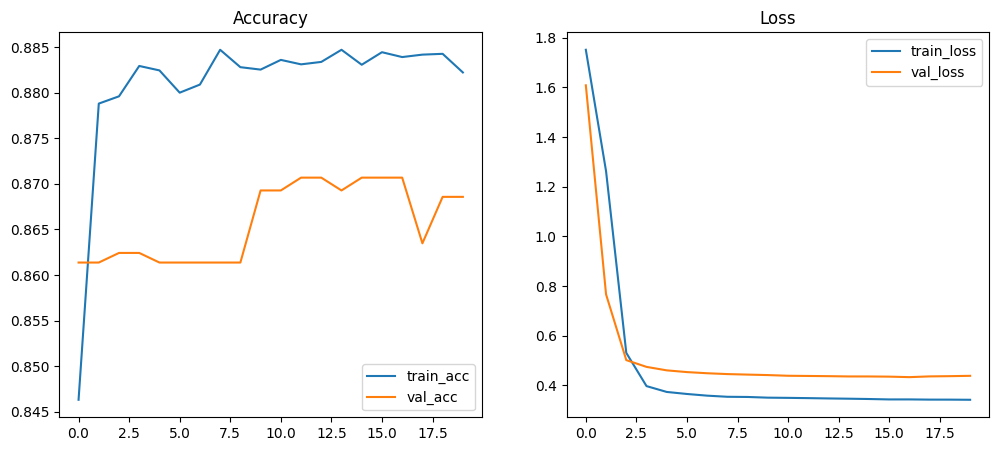

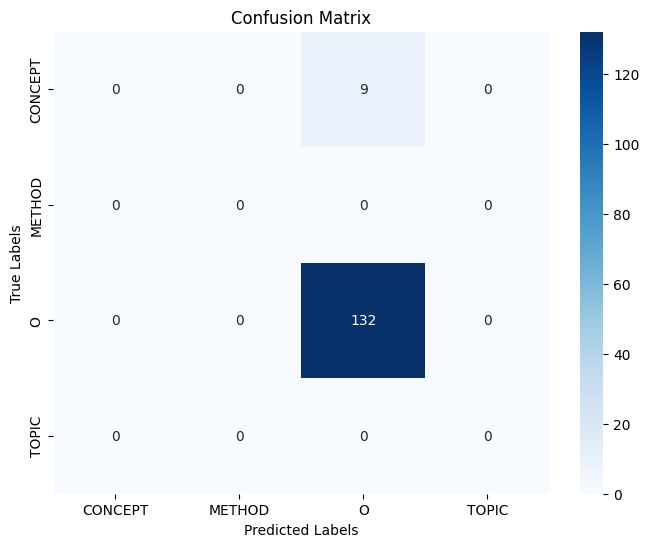

In [1]:
# ========================
# BiLSTM + Attention for NER
# ========================

# -----------------------------
# IMPORTS
# -----------------------------
import os, zipfile, json, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, TimeDistributed, Layer
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# ATTENTION LAYER
# -----------------------------
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], input_shape[-1]),
                                 initializer="random_normal", trainable=True)
        self.b = self.add_weight(name="att_bias", shape=(input_shape[-1],), initializer="zeros", trainable=True)
        self.u = self.add_weight(name="att_u", shape=(input_shape[-1], 1), initializer="random_normal", trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        u_it = tf.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)  # (batch, time, hidden)
        att = tf.nn.softmax(tf.tensordot(u_it, self.u, axes=1), axis=1)  # (batch, time, 1)
        output = tf.reduce_sum(inputs * att, axis=1)  # weighted sum over time
        output = tf.repeat(tf.expand_dims(output, axis=1), repeats=inputs.shape[1], axis=1)  # repeat for each time step
        return output

# -----------------------------
# DATASET EXTRACTION
# -----------------------------
zip_path = '/content/drive/MyDrive/Colab Notebooks/FYP /OOP Annotated.zip'
extract_path = '/content/extracted_data'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print(f"Dataset extracted to: {extract_path}")

# -----------------------------
# LOAD ANNOTATIONS
# -----------------------------
def load_spacy_annotations(base_path):
    sentences, labels, tag_set = [], [], set()
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if "annotations (1)" in file and file.endswith(".json"):
                file_path = os.path.join(root, file)
                try:
                    with open(file_path, "r", encoding="utf-8") as f:
                        data = json.load(f)
                    if "annotations" not in data:
                        continue
                    for text, ann in data["annotations"]:
                        if not text.strip():
                            continue
                        tokens = text.strip().split()
                        token_labels = ["O"] * len(tokens)
                        for start, end, label in ann.get("entities", []):
                            span_text = text[start:end]
                            for i, token in enumerate(tokens):
                                if span_text in token:
                                    token_labels[i] = label
                                    tag_set.add(label)
                        sentences.append(tokens)
                        labels.append(token_labels)
                except Exception as e:
                    print(f"[WARN] Skipping {file_path}: {e}")
    return sentences, labels, tag_set

base_path = "/content/extracted_data/OOP Annotated"
sentences, labels, tag_set = load_spacy_annotations(base_path)

print("Total sentences:", len(sentences))
print("Sample sentence:", sentences[0])
print("Sample labels:", labels[0])
print("Tags found:", tag_set)

# -----------------------------
# PREPROCESSING
# -----------------------------
all_words = set([w for s in sentences for w in s])
all_tags = sorted(list(set([t for l in labels for t in l])))

word2idx = {w: i+2 for i, w in enumerate(sorted(all_words))}
word2idx["PAD"] = 0
word2idx["UNK"] = 1

tag2idx = {t: i+1 for i, t in enumerate(all_tags)}
tag2idx["PAD"] = 0
idx2tag = {i: t for t, i in tag2idx.items()}

X = [[word2idx.get(w, word2idx["UNK"]) for w in s] for s in sentences]
y = [[tag2idx[t] for t in l] for l in labels]

MAXLEN = max(len(s) for s in X)
X = pad_sequences(X, maxlen=MAXLEN, padding="post", value=word2idx["PAD"])
y = pad_sequences(y, maxlen=MAXLEN, padding="post", value=tag2idx["PAD"])

# -----------------------------
# TRAIN/TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# MODEL BUILD
# -----------------------------
EMBEDDING_DIM = 128
LSTM_UNITS = 64
NUM_CLASSES = len(tag2idx)

input_layer = Input(shape=(MAXLEN,))
x = Embedding(input_dim=len(word2idx), output_dim=EMBEDDING_DIM, mask_zero=True)(input_layer)
x = Bidirectional(LSTM(LSTM_UNITS, return_sequences=True, dropout=0.3, recurrent_dropout=0.3))(x)
x = AttentionLayer()(x)
output_layer = TimeDistributed(Dense(NUM_CLASSES, activation="softmax"))(x)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

# -----------------------------
# TRAIN MODEL
# -----------------------------
history = model.fit(
    X_train, np.expand_dims(y_train, -1),
    validation_data=(X_test, np.expand_dims(y_test, -1)),
    batch_size=16,
    epochs=20,
    verbose=1
)

# -----------------------------
# EVALUATION
# -----------------------------
y_pred = model.predict(X_test)
y_true_labels, y_pred_labels = [], []

for i in range(len(y_test)):
    for j in range(len(y_test[i])):
        if y_test[i][j] != tag2idx["PAD"]:
            y_true_labels.append(idx2tag[y_test[i][j]])
            y_pred_labels.append(idx2tag[np.argmax(y_pred[i][j])])

print(classification_report(y_true_labels, y_pred_labels, zero_division=0))

# -----------------------------
# PLOT ACCURACY & LOSS
# -----------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()
plt.show()

# -----------------------------
# CONFUSION MATRIX
# -----------------------------
labels_present = sorted(list(set(y_true_labels)))
cm = confusion_matrix(y_true_labels, y_pred_labels, labels=labels_present)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels_present, yticklabels=labels_present, cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("True Labels")
plt.xlabel("Predicted Labels")
plt.show()
